# CelebA-HQ: per-seed benchmark

All methods on 5 memorized and 5 non-memorized seeds of the fine-tuned latent EDM. Writes `cache/benchmark.pt`, `results/per_seed.csv`, `all_figures/celeba_hq_memorized.pdf`, `all_figures/celeba_hq_memorized_main.pdf` and `all_figures/celeba_hq_non_memorized.pdf`.

In [1]:
import json, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/guidance").exists())
sys.path.insert(0, str(ROOT / "src"))
from baselines import broken_memories as bm
from models import celeba_hq_edm as E
from plotting import wsstyle

EXP = ROOT / "experiments/celeba_hq"
CACHE, RESULTS = EXP / "cache", EXP / "results"
CACHE.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)

device = os.environ.get("DEVICE") or ("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
config = {
    "memorized_seeds": [22, 20, 21, 11, 15],
    # hand-screened, see "Run"
    "non_memorized_seeds": [125, 75, 87, 85, 88],
    "amg_c3_sweep": [0.1, 0.3, 1, 3, 10],
    # sweeps vary one control around the paper point (threshold scale 1, k=10, gamma=3)
    "bm_calibration_seeds": [s for s in range(50) if s not in [12, 22, 24, 0, 20, 6, 15, 21, 11, 7]], "bm_std_floor": 1e-5,
    "bm_threshold_scales": [1.0, 0.5, 0.25, 0.1],
    "bm_durations": [6, 16, 24, 31, 32],          # at threshold scale 0.1
    "bm_projection_widths": [2.0, 1.0, 0.5],      # at threshold scale 0.1, k = 32
}
METHODS = ["unguided", "fr", "bayesian_fr", "random", "amg", "bm"]
LABELS = {m: wsstyle.METHOD_LABELS[m] for m in METHODS}
N_STEPS = E.N_STEPS

model = E.load(device)
print(f"device={device}, sigma_data={model['sigma_data']:.4f}, training latents={tuple(model['X_train'].shape)}")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


device=mps, sigma_data=0.9241, training latents=(200, 4, 32, 32)


## Operating points

AMG: mildest $c_3$ moving the most memorized seeds above the ratio threshold. Broken Memories: sweep setting with the highest mean $d_1/d_2$ on the memorized seeds (ties to the milder).

## Samplers and cache

Shared 32-step Heun EDM sampler and initial noise per seed; AMG searches the training images in pixel space (paper, Supp. D).

In [2]:
def bm_operating_point():
    return {"threshold_scale": config["bm_threshold_scale"], "mild_steps": config["bm_mild_steps"], "gamma": config["bm_gamma"]}

def run_key(method, seed, amg_c3=None, bm_setting=None):
    if method == "unguided":
        return f"unguided|seed={seed}"
    if method in ("fr", "bayesian_fr", "random"):
        return f"{method}|seed={seed}|" + "|".join(f"{k}={v}" for k, v in E.FR_SETTINGS.items())
    if method == "amg":
        return f"amg-paper|seed={seed}|c3={amg_c3 if amg_c3 is not None else config['amg_c3']:g}"
    s = bm_setting or bm_operating_point()
    return f"bm|seed={seed}|scale={s['threshold_scale']:g}|k={s['mild_steps']}|gamma={s['gamma']:g}"

SAMPLERS = {
    "unguided": lambda seed, amg_c3, bm_setting: E.unguided(model, seed),
    "fr": lambda seed, amg_c3, bm_setting: E.fr(model, seed),
    "bayesian_fr": lambda seed, amg_c3, bm_setting: E.fr(model, seed, bayesian=True),
    "random": lambda seed, amg_c3, bm_setting: E.random(model, seed),
    "amg": lambda seed, amg_c3, bm_setting: E.amg(model, seed, amg_c3 if amg_c3 is not None else config["amg_c3"]),
    "bm": lambda seed, amg_c3, bm_setting: E.broken_memories(model, seed, bm_stats, **(bm_setting or bm_operating_point())),
}

def file_signature(path):
    stat = Path(path).resolve().stat()
    return {"path": str(Path(path).resolve()), "size": stat.st_size, "mtime_ns": stat.st_mtime_ns}

CACHE_FILE = CACHE / "benchmark.pt"
signature = {"version": 2, "device": device, "model": file_signature(model["ckpt_path"]),
             "bm_calibration": {"seeds": config["bm_calibration_seeds"], "std_floor": config["bm_std_floor"]}}
cache = torch.load(CACHE_FILE, map_location="cpu", weights_only=False) if CACHE_FILE.exists() else {}
if cache.get("signature") != signature:
    cache = {"signature": signature, "runs": {}}

def run(method, seed, amg_c3=None, bm_setting=None):
    """amg_c3 / bm_setting override the AMG / Broken Memories operating point for their sweeps."""
    key = run_key(method, seed, amg_c3, bm_setting)
    if key not in cache["runs"]:
        start = time.perf_counter()
        result = SAMPLERS[method](seed, amg_c3, bm_setting)
        result["seconds"] = time.perf_counter() - start
        cache["runs"][key] = result
        torch.save(cache, CACHE_FILE)
    return cache["runs"][key]

def memorization(z):
    return E.memorization(model, z)

cache.setdefault("images", {})
def decoded(key, z):
    if key not in cache["images"]:
        cache["images"][key] = E.decode(model, z)
    return cache["images"][key]

## Broken Memories calibration

Stability regions from unguided trajectories of seeds 0-49 minus the known memorized seeds.

In [3]:
for seed in config["memorized_seeds"] + config["non_memorized_seeds"]:
    assert seed not in config["bm_calibration_seeds"], f"seed {seed} calibrates Broken Memories"
if "bm_stats" not in cache:
    normal, rows = [], []
    for seed in config["bm_calibration_seeds"]:
        endpoint, trace = E.norm_trace(model, seed)
        ratio = memorization(endpoint)["ratio"]
        rows.append({"seed": seed, "ratio": ratio, "normal": ratio >= E.RATIO_THRESHOLD})
        if rows[-1]["normal"]:
            normal.append(trace)
    assert len(normal) >= 20, f"only {len(normal)} normal calibration trajectories"
    cache["bm_stats"] = bm.calibrate({name: torch.stack([t[name] for t in normal]) for name in bm.NORMS},
                                     std_floor=config["bm_std_floor"])
    cache["bm_calibration_table"] = pd.DataFrame(rows)
    torch.save(cache, CACHE_FILE)
bm_stats = cache["bm_stats"]
calibration = cache["bm_calibration_table"]
print(f"{int(calibration.normal.sum())} of {len(calibration)} calibration trajectories are non-memorized")

34 of 40 calibration trajectories are non-memorized


## Run

Non-memorized seeds were screened by eye on unguided seeds 50-149 (sharp, $d_1/d_2 > 0.8$, not an identity copy) before any method was run.

In [4]:
amg_sweep = pd.DataFrame([{"c3": c3, "seed": seed, **memorization(run("amg", seed, c3)["z"]),
                           "active_steps": int(run("amg", seed, c3)["active"].sum())}
                          for c3 in config["amg_c3_sweep"] for seed in config["memorized_seeds"]])
amg_summary = (amg_sweep.assign(escaped=~amg_sweep.is_memorized).groupby("c3")
               .agg(n_escaped=("escaped", "sum"), mean_ratio=("ratio", "mean"), mean_active_steps=("active_steps", "mean")))
config["amg_c3"] = float(amg_summary.index[amg_summary.n_escaped.eq(amg_summary.n_escaped.max())].min())
display(amg_summary.round(3))
print(f"AMG: c3={config['amg_c3']:g}")

BM_SWEEP = ([{"name": "paper" if s == 1 else f"tau-scale={s:g}", "threshold_scale": s, "mild_steps": 10, "gamma": 3.0}
             for s in config["bm_threshold_scales"]]
            + [{"name": f"k={k}", "threshold_scale": 0.1, "mild_steps": k, "gamma": 3.0} for k in config["bm_durations"]]
            + [{"name": f"gamma={g:g}", "threshold_scale": 0.1, "mild_steps": N_STEPS, "gamma": g}
               for g in config["bm_projection_widths"]])
bm_args = lambda s: {k: s[k] for k in ["threshold_scale", "mild_steps", "gamma"]}
bm_sweep = pd.DataFrame([{**s, "mean_ratio": np.mean([memorization(run("bm", seed, bm_setting=bm_args(s))["z"])["ratio"]
                                                      for seed in config["memorized_seeds"]]),
                          "mean_active_steps": np.mean([int(run("bm", seed, bm_setting=bm_args(s))["active"].sum())
                                                        for seed in config["memorized_seeds"]])} for s in BM_SWEEP])
best = bm_sweep.loc[bm_sweep.mean_ratio.round(4).idxmax()]   # first maximum in sweep order
config.update(bm_setting=best["name"], bm_threshold_scale=float(best.threshold_scale), bm_mild_steps=int(best.mild_steps),
              bm_gamma=float(best.gamma))
(CACHE / "operating_points.json").write_text(json.dumps({"amg": {"c3": config["amg_c3"]}, "bm": {"name": config["bm_setting"], **bm_operating_point()}}, indent=1))
display(bm_sweep.round(3))
print(f"Broken Memories: {best['name']} (threshold scale={config['bm_threshold_scale']:g}, "
      f"k={config['bm_mild_steps']}, gamma={config['bm_gamma']:g})")

SEED_GROUPS = {"memorized": config["memorized_seeds"], "non-memorized": config["non_memorized_seeds"]}
for seed in config["non_memorized_seeds"]:
    assert seed not in config["bm_calibration_seeds"], f"seed {seed} was used to calibrate Broken Memories"

for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        for method in METHODS:
            result = run(method, seed)
            m = memorization(result["z"])
            print(f"{group:<13} seed={seed:>3} {LABELS[method]:<16} ratio={m['ratio']:.3f} "
                  f"active steps={int(result['active'].sum()):>2} ({result['seconds']:.1f}s)")

,n_escaped,mean_ratio,mean_active_steps
c3,,,
0.1,0,0.191,32.0
0.3,1,0.327,32.0
1.0,2,0.398,32.0
3.0,3,0.421,32.0
10.0,5,0.767,30.4


AMG: c3=10


,name,threshold_scale,mild_steps,gamma,mean_ratio,mean_active_steps
0,paper,1.00,10,3.0,0.191,0.0
1,tau-scale=0.5,0.50,10,3.0,0.191,0.0
2,tau-scale=0.25,0.25,10,3.0,0.196,1.8
3,tau-scale=0.1,0.10,10,3.0,0.174,10.4
4,k=6,0.10,6,3.0,0.170,8.8
5,k=16,0.10,16,3.0,0.171,13.2
6,k=24,0.10,24,3.0,0.211,17.8
7,k=31,0.10,31,3.0,0.216,20.6
8,k=32,0.10,32,3.0,0.216,21.0
9,gamma=2,0.10,32,2.0,0.216,21.0


Broken Memories: gamma=1 (threshold scale=0.1, k=32, gamma=1)
memorized     seed= 22 Unguided         ratio=0.126 active steps= 0 (1.8s)
memorized     seed= 22 FR               ratio=1.000 active steps=21 (3.6s)
memorized     seed= 22 Bayesian FR      ratio=1.000 active steps=21 (3.3s)
memorized     seed= 22 Random perturbations ratio=0.124 active steps=21 (1.9s)
memorized     seed= 22 AMG              ratio=0.839 active steps=31 (50.7s)
memorized     seed= 22 Broken Memories  ratio=0.173 active steps=27 (2.8s)
memorized     seed= 20 Unguided         ratio=0.192 active steps= 0 (1.8s)
memorized     seed= 20 FR               ratio=0.999 active steps=21 (3.3s)
memorized     seed= 20 Bayesian FR      ratio=1.000 active steps=21 (3.3s)
memorized     seed= 20 Random perturbations ratio=0.198 active steps=21 (1.9s)
memorized     seed= 20 AMG              ratio=0.683 active steps=32 (51.7s)
memorized     seed= 20 Broken Memories  ratio=0.115 active steps=32 (2.8s)
memorized     seed= 21 Ungui

## Per-seed results

`ratio`: $d_1/d_2$ vs. the 200 fine-tuning latents (below $1/3$ is memorized); `displacement`: $\lVert z - z_{\text{unguided}}\rVert / \lVert z_{\text{unguided}}\rVert$; `active_steps`: steps with an intervention.

In [5]:
rows = []
for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        z_base = run("unguided", seed)["z"]
        for method in METHODS:
            result = run(method, seed)
            rows.append({"group": group, "seed": seed, "method": LABELS[method],
                         **memorization(result["z"]),
                         "displacement": ((result["z"] - z_base).norm() / z_base.norm()).item(),
                         "active_steps": int(result["active"].sum()), "seconds": result["seconds"]})
results = pd.DataFrame(rows)
results.to_csv(RESULTS / "per_seed.csv", index=False)
for value in ["ratio", "displacement"]:
    table = results.pivot_table(index=["group", "seed"], columns="method", values=value, sort=False)
    display(table[[LABELS[m] for m in METHODS]].round(3))

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     22       0.126  1.000        1.000                 0.124  0.839   
              20       0.192  0.999        1.000                 0.198  0.683   
              21       0.208  0.999        1.000                 0.217  0.534   
              11       0.223  0.968        0.998                 0.204  0.982   
              15       0.206  1.000        1.000                 0.898  0.799   
non-memorized 125      0.931  1.000        1.000                 0.929  0.990   
              75       0.965  0.999        1.000                 0.857  0.671   
              87       0.968  1.000        0.993                 0.921  0.511   
              85       0.806  0.999        0.999                 0.957  0.957   
              88       0.972  1.000        0.999                 0.974  0.967   

method              Broken Memories  
group         seed                   
memorized     22              0.173  
              20              0.115  
              21              0.208  
              11              0.314  
              15              0.269  
non-memorized 125             0.990  
              75              0.805  
              87              0.960  
              85              0.982  
              88              0.950

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     22         0.0  0.999        0.906                 0.015  0.709   
              20         0.0  1.015        1.043                 0.012  0.829   
              21         0.0  0.946        0.870                 0.016  1.170   
              11         0.0  0.854        0.876                 0.022  0.772   
              15         0.0  1.012        1.061                 0.897  1.023   
non-memorized 125        0.0  0.560        0.507                 0.054  0.700   
              75         0.0  0.634        0.520                 0.430  0.869   
              87         0.0  0.852        0.837                 0.367  0.759   
              85         0.0  0.820        0.918                 0.506  0.988   
              88         0.0  0.464        0.419                 0.095  0.830   

method              Broken Memories  
group         seed                   
memorized     22              0.132  
              20              0.984  
              21              0.000  
              11              0.228  
              15              1.121  
non-memorized 125             0.434  
              75              0.547  
              87              0.362  
              85              0.711  
              88              0.199

## Decode

In [6]:
tiles = {}
for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        for method in METHODS:
            key = run_key(method, seed)
            tiles[(seed, method)] = {"gen": decoded(key, cache["runs"][key]["z"]),
                                     "nn": E.load_train_image(model, memorization(cache["runs"][key]["z"])["nn_idx"])}
torch.save(cache, CACHE_FILE)

## Figure

Generated face and nearest training image per method and seed.

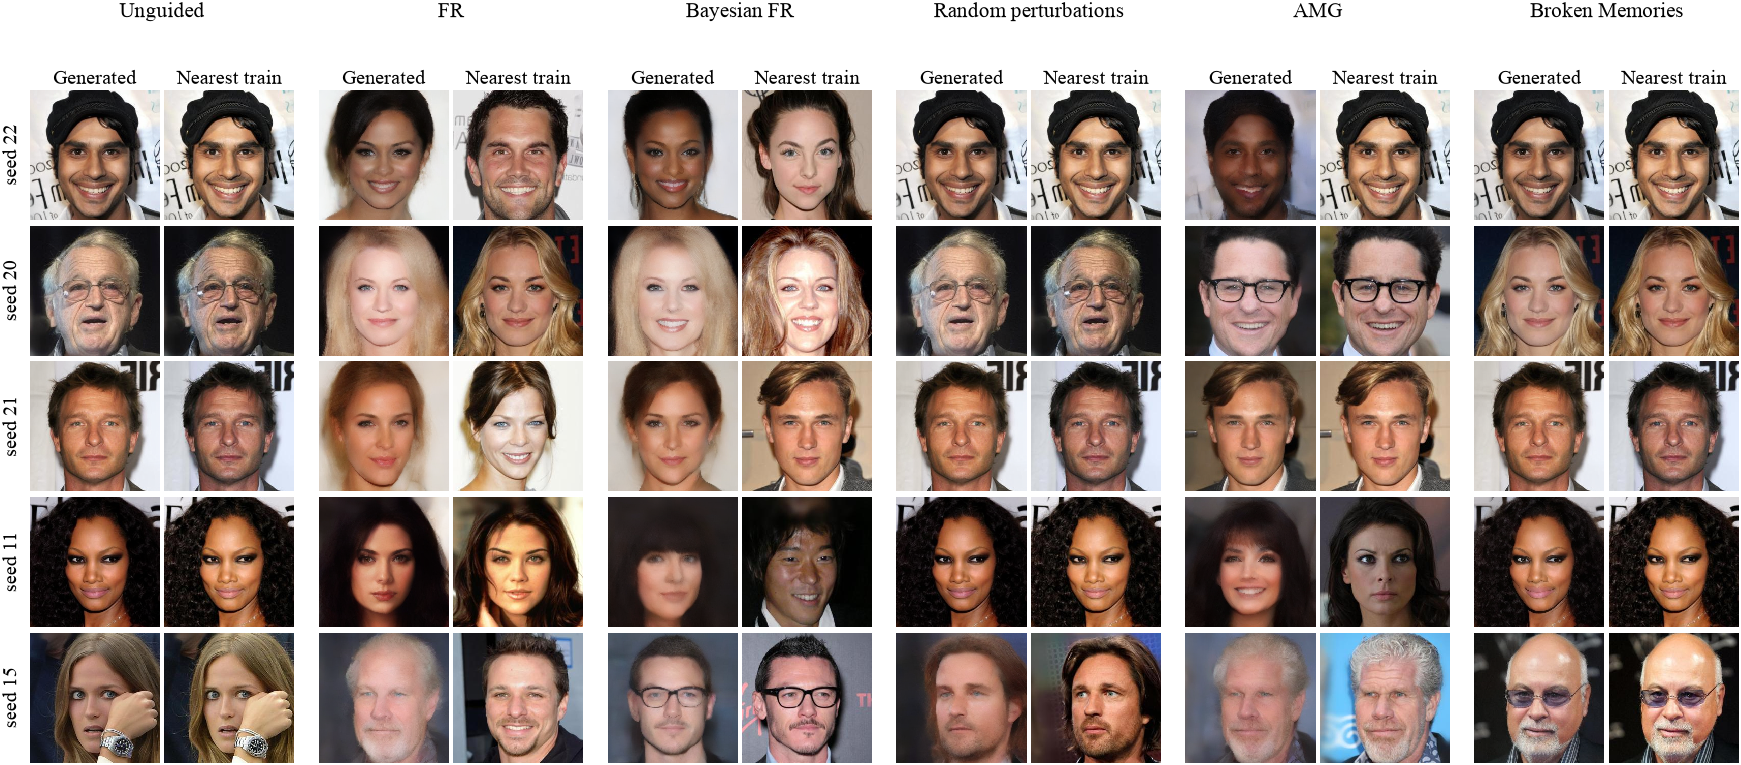

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/all_figures/celeba_hq_memorized.pdf']


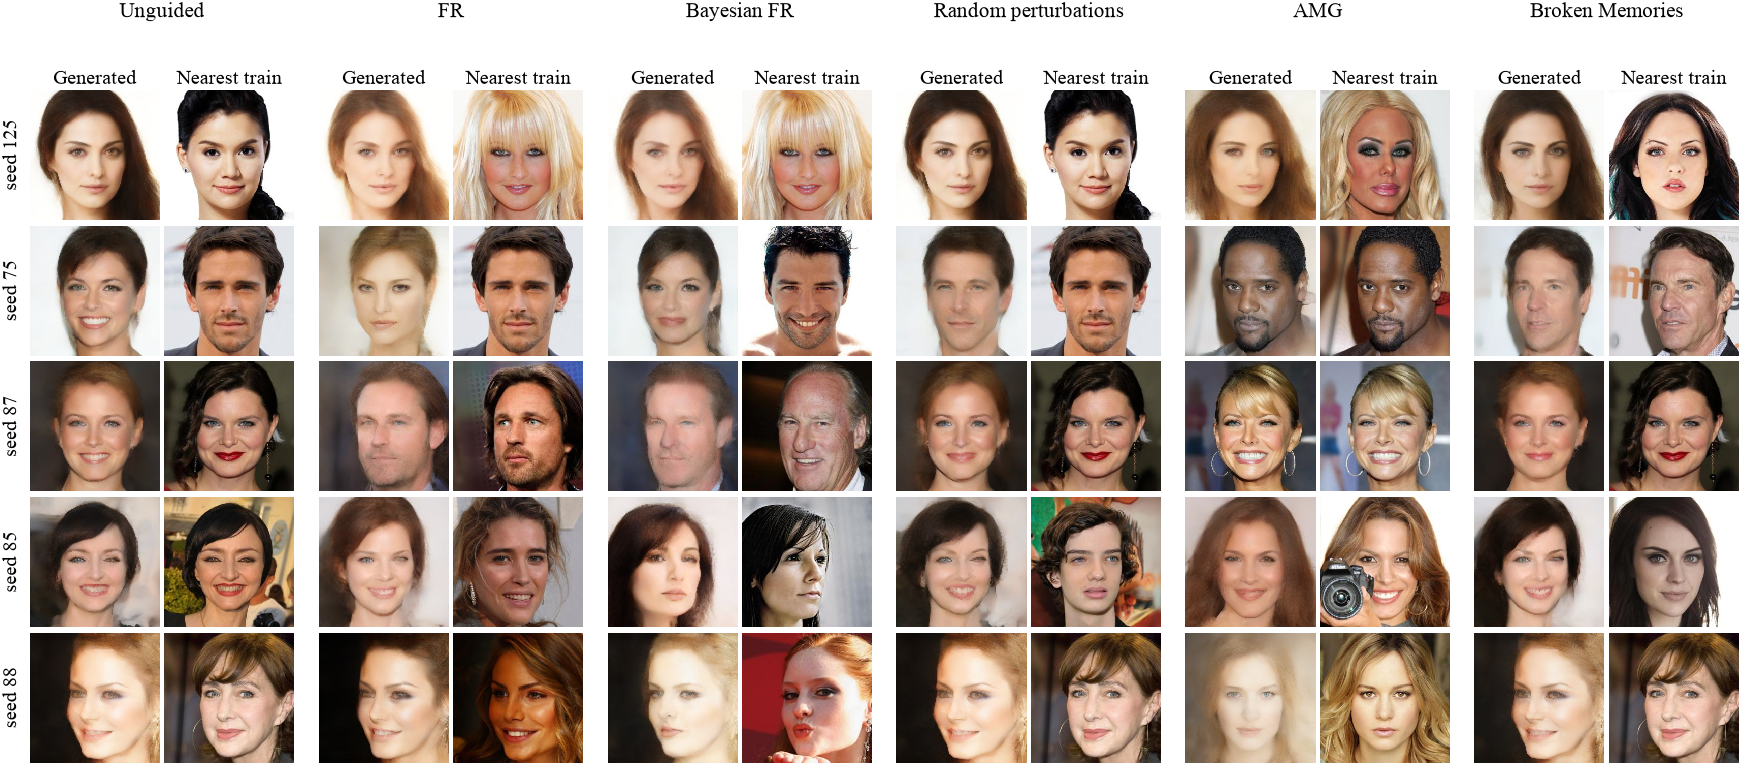

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/all_figures/celeba_hq_non_memorized.pdf']


In [7]:
wsstyle.paper_style()

def show(ax, image, edge):
    ax.imshow(image.permute(1, 2, 0).numpy(), interpolation="nearest")
    wsstyle.strip_axes(ax)

def draw_methods_figure(seeds, name):
    """One block per method (generated sample, nearest training image), one row per seed, at the paper's full width."""
    n_blocks, n_rows = len(METHODS), len(seeds)
    width, left, right, top, bottom = wsstyle.FULL_WIDTH, 0.42, 0.04, 0.92, 0.04
    tile_gap, block_gap, row_gap = 0.04, 0.22, 0.05
    tile = (width - left - right - n_blocks * tile_gap - (n_blocks - 1) * block_gap) / (2 * n_blocks)
    height = top + bottom + n_rows * tile + (n_rows - 1) * row_gap
    fig = plt.figure(figsize=(width, height))
    rect = lambda x, y: [x / width, 1 - (y + tile) / height, tile / width, tile / height]

    block_x = [left + b * (2 * tile + tile_gap + block_gap) for b in range(n_blocks)]
    for i, seed in enumerate(seeds):
        y = top + i * (tile + row_gap)
        for b, method in enumerate(METHODS):
            for j, kind in enumerate(["gen", "nn"]):
                ax = fig.add_axes(rect(block_x[b] + j * (tile + tile_gap), y))
                show(ax, tiles[(seed, method)][kind], "#7A7A7A" if kind == "gen" else "#D0D0D0")
                if i == 0:
                    ax.set_title(["Generated", "Nearest train"][j], fontsize=wsstyle.FONT_SIZE, pad=4)
                if b == 0 and j == 0:
                    ax.set_ylabel(f"seed {seed}", labelpad=6, fontsize=wsstyle.FONT_SIZE)

    for b, method in enumerate(METHODS):
        x0, x1 = block_x[b] / width, (block_x[b] + 2 * tile + tile_gap) / width
        fig.text(0.5 * (x0 + x1), 1 - 0.30 / height, LABELS[method], ha="center", va="bottom", fontsize=wsstyle.TITLE_SIZE)
    paths = wsstyle.save(fig, name)
    plt.show()
    return paths

for group in SEED_GROUPS:
    print(draw_methods_figure(SEED_GROUPS[group], f"celeba_hq_{group.replace('-', '_')}"))

## Figure: main-body version

Same layout as the full grid above, restricted to three memorized seeds.

main-body seeds: [22, 20, 15]


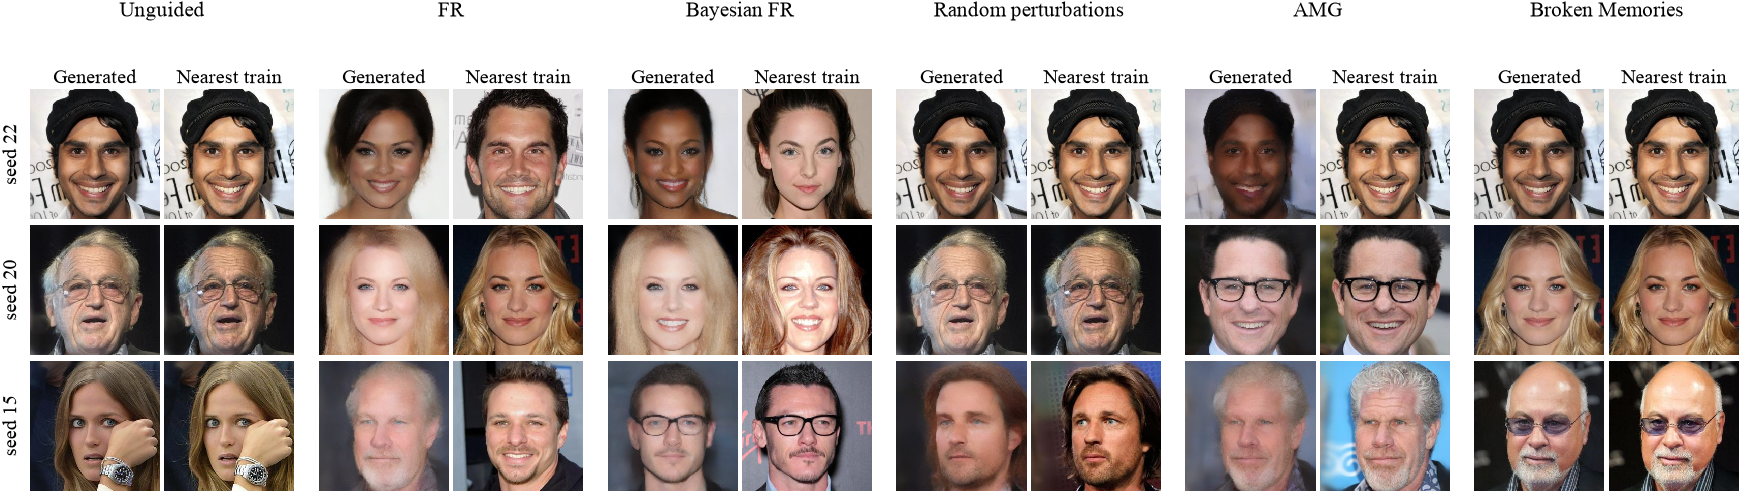

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/all_figures/celeba_hq_memorized_main.pdf']


In [8]:
# main body: the 3 most memorized seeds under unguided sampling (lowest ratio); the full grids above go to the appendix
per_seed = pd.read_csv(RESULTS / "per_seed.csv")
MAIN_SEEDS = (per_seed[per_seed.group.eq("memorized") & per_seed.method.eq(LABELS["unguided"])]
              .nsmallest(3, "ratio").seed.tolist())
print("main-body seeds:", MAIN_SEEDS)
print(draw_methods_figure(MAIN_SEEDS, "celeba_hq_memorized_main"))